In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
%pip install google-cloud-bigquery pandas-gbq

Note: you may need to restart the kernel to use updated packages.


In [5]:
from google.cloud import bigquery
import pandas as pd

# Set up BigQuery Client
client = bigquery.Client(project="scalable-streaming-analytics")

# Define the SQL Query
query = """
SELECT * 
FROM `scalable-streaming-analytics.streaming_data.events`
LIMIT 10
"""

# Execute the Query
df = client.query(query).to_dataframe()

# Display Data
df.head()



c:\Users\bthea\scalable-streaming-analytics\venv\Lib\site-packages\google\cloud\bigquery\table.py:1820: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,event,content_id,timestamp
0,1,watch,content_5,1.739140e+09


In [6]:
import pandas as pd

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s')

# Check for missing values
print(df.isnull().sum())

# Display summary statistics
print(df.describe())

# Display first few rows
df.head()


user_id       0
event         0
content_id    0
timestamp     0
dtype: int64
       user_id            timestamp
count      1.0                    1
mean       1.0  2025-02-09 22:28:09
min        1.0  2025-02-09 22:28:09
25%        1.0  2025-02-09 22:28:09
50%        1.0  2025-02-09 22:28:09
75%        1.0  2025-02-09 22:28:09
max        1.0  2025-02-09 22:28:09
std       <NA>                  NaN


,user_id,event,content_id,timestamp
0,1,watch,content_5,2025-02-09 22:28:09


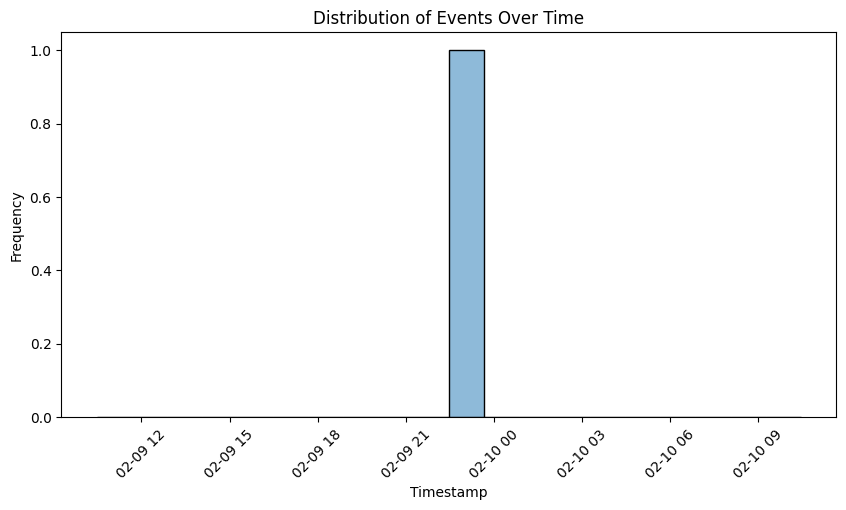

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot events over time
plt.figure(figsize=(10, 5))
sns.histplot(df['timestamp'], bins=20, kde=True)
plt.xlabel('Timestamp')
plt.ylabel('Frequency')
plt.title('Distribution of Events Over Time')
plt.xticks(rotation=45)
plt.show()


In [8]:
# Check the latest entries
query = """
SELECT * FROM `scalable-streaming-analytics.streaming_data.events`
ORDER BY timestamp DESC
LIMIT 10
"""
df = client.query(query).to_dataframe()
df.head()


c:\Users\bthea\scalable-streaming-analytics\venv\Lib\site-packages\google\cloud\bigquery\table.py:1820: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,user_id,event,content_id,timestamp
0,1,watch,content_5,1.739140e+09
